In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [4]:
df = pd.read_csv("loan_approval_data.csv")

In [41]:
df.info()
# df.isnull().sum()
# df.describe()
df["Employment_Status"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

0           Salaried
1           Salaried
2           Salaried
3           Salaried
4      Self-employed
           ...      
995         Salaried
996    Self-employed
997         Contract
998       Unemployed
999         Salaried
Name: Employment_Status, Length: 1000, dtype: object

In [12]:
# 1 Handling Missing Values

# Dividing Columns based on Data types: cause we handle them seperately!
categorical_cols = df.select_dtypes(include = ["object"]).columns
numerical_cols = df.select_dtypes(include = ["float64"]).columns

In [16]:
num_imp = SimpleImputer(strategy='mean')
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [19]:
cat_imp = SimpleImputer(strategy = "most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [22]:
# Veryfying null 
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

In [53]:
df["Dependents"]

0      0.0
1      3.0
2      2.0
3      2.0
4      2.0
      ... 
995    0.0
996    1.0
997    1.0
998    1.0
999    1.0
Name: Dependents, Length: 1000, dtype: float64

# EDA - Exploratory Data Analysis

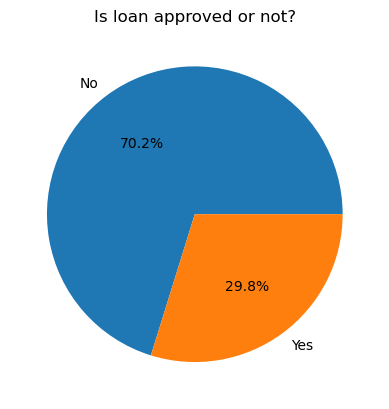

In [24]:
#  How balanced our classes are?

classes_count = df["Loan_Approved"].value_counts()
classes_count
plt.pie(classes_count, labels = ["No", "Yes"], autopct = "%1.1f%%")
plt.title("Is loan approved or not?")
plt.show()

[Text(0, 0, '621'), Text(0, 0, '379')]

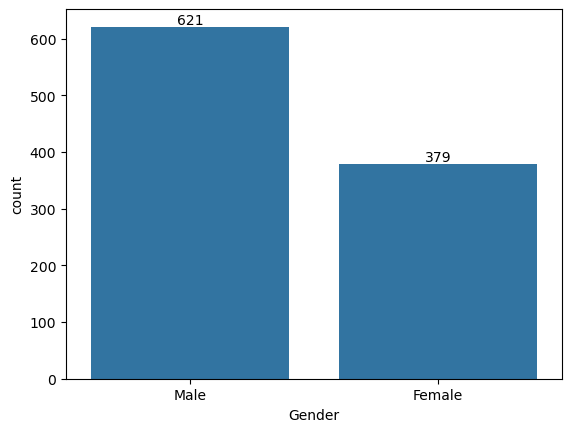

In [72]:
# Analyze Categories

#  Gender
gender_count = df["Gender"].value_counts()
ax = sns.barplot(gender_count)
ax.bar_label(ax.containers[0])

# Education Level
# edu_count = df["Education_Level"].value_counts()
# ax = sns.barplot(edu_count)
# ax.bar_label(ax.containers[0])

# Applicant_Income
# income_count = df["Applicant_Income"].value_counts()
# ax = sns.scatterplot(income_count)

# Coapplicant_Income 
# coapplicant_count = df["Coapplicant_Income"].value_counts()
# ax = sns.scatterplot(coapplicant_count)

# Employment_Status 
# employment_sts_count = df["Employment_Status"].value_counts()
# ax = sns.barplot(employment_sts_count)

# Age
# age_count = df["Age"].value_counts()
# ax = sns.scatterplot(age_count)

# Marital_Status 
# marital_sts_count = df["Marital_Status"].value_counts()
# ax = sns.barplot(marital_sts_count)
# ax.bar_label(ax.containers[0])

# Dependents_count = df["Dependents"].value_counts()
# ax = sns.barplot(Dependents_count)
# ax.bar_label(ax.containers[0])

# Existing_Loans_count = df["Existing_Loans"].value_counts()
# ax = sns.barplot(Existing_Loans_count)
# ax.bar_label(ax.containers[0])

# Savings_count = df["Savings"].value_counts()
# ax = sns.scatterplot(Savings_count)
# ax.bar_label(ax.containers[0])


<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

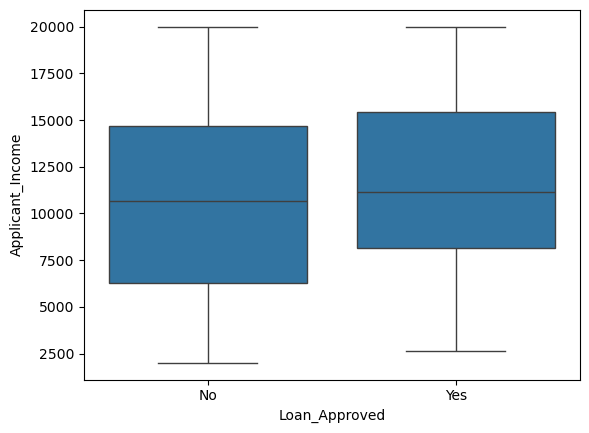

In [73]:
# Outliers - Outlier detection

sns.boxplot(
    data= df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)


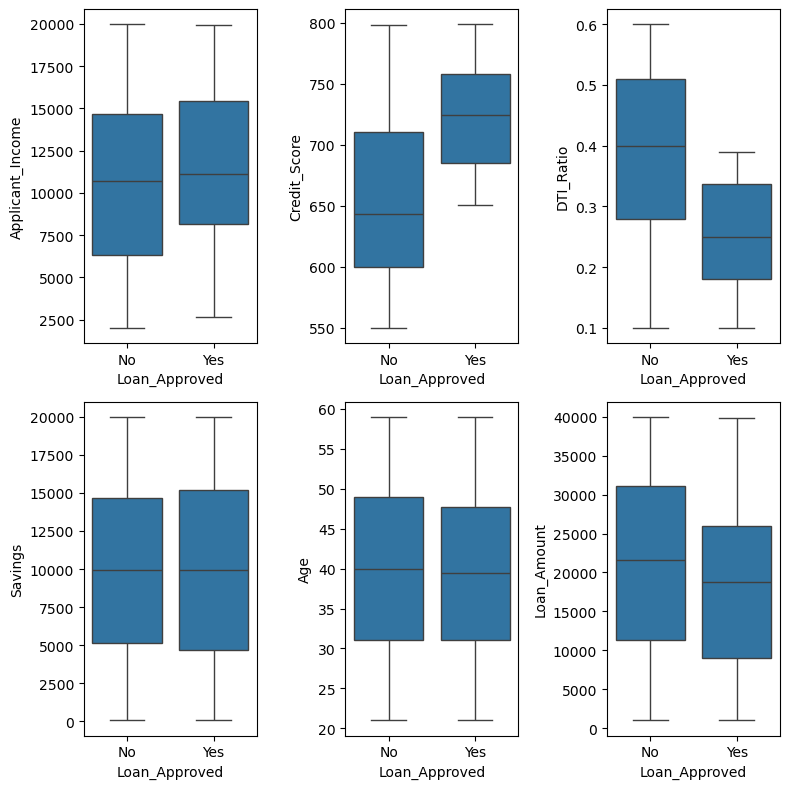

In [84]:
fig, axes = plt.subplots(2,3, figsize = (8,8))

sns.boxplot(ax = axes[0,0], data = df, x = "Loan_Approved", y = "Applicant_Income")
sns.boxplot(ax = axes[0,1], data = df, x = "Loan_Approved", y = "Credit_Score")
sns.boxplot(ax = axes[0,2], data = df, x = "Loan_Approved", y = "DTI_Ratio")
sns.boxplot(ax = axes[1,0], data = df, x = "Loan_Approved", y = "Savings")
sns.boxplot(ax = axes[1,1], data = df, x = "Loan_Approved", y = "Age")
sns.boxplot(ax = axes[1,2], data = df, x = "Loan_Approved", y = "Loan_Amount")

fig.tight_layout()
plt.tight_layout()